# Fell & Heisenberg 2021 Reproduction (Phase 3 of audit-synthesis-fell-heisenberg plan)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/fell_heisenberg.ipynb)

**Runtime:** local for the symbolic pipeline cells (1–4) and the small-grid numerical reproductions (5–8); Colab CPU is recommended for the high-resolution 3D grid sweep (cells 9–11).

**Goal.** Independent reproduction of the central computational claim of Fell & Heisenberg 2021 (arXiv: [2104.06488](https://arxiv.org/abs/2104.06488)): **a multi-component shift vector field $\vec{N} = \vec{\nabla}\phi$ derived from a $C^2$ scalar potential can produce a positive Eulerian energy density $\rho_E = T_{\mu\nu} n^\mu n^\nu$ everywhere on a 3D grid, while still admitting a superluminal central shift magnitude.**

**Critical caveat (already established by reading the paper itself; see [`FELL_HEISENBERG2021_EVALUATION.md`](FELL_HEISENBERG2021_EVALUATION.md) §TL;DR):** Fell & Heisenberg explicitly admit in their §3.3 that the *full* WEC ($\rho + p_i^p \ge 0$ for all principal pressures) and the *full* DEC ($\rho \ge |p_i^p|$) are violated in compact regions of their construction. Their headline 'positive energy' refers specifically to the Eulerian energy density (the timelike eigenvalue of the stress-energy tensor) and not to the principal-pressure-incorporating tests that we used in Slice 1 of Phase 2C. 

So the *interesting* computational questions are:
1. Does our pipeline reproduce their Eulerian-energy-positivity claim on their explicit construction? (Eq. WECinirrotationalhelmholtz: $8\pi\rho_E = h_1 + h_2 + h_3$.)
2. Where do the full-WEC violations actually live, and how big are they?
3. How does the integrated Eulerian energy compare to their reported $\sim 10^{-4} M_\odot$?

**Method.** We work in Cartesian coordinates with unit lapse $N = 1$ and flat spatial metric $\gamma_{ij} = \delta_{ij}$, exactly as Fell-Heisenberg do. The 4D metric (their Eq. METRICLINEELEMENT) is then $g_{\mu\nu} = \text{diag}(-1 + N_i N^i, +I_3) + \text{shift terms}$. We build the symbolic Einstein tensor of this metric in SymPy (Part A), then reduce it to fast NumPy callables for 3D grid evaluation (Part B). All energy condition checks are done in the orthonormal Eulerian frame.

**Conventions.** Signature $(-, +, +, +)$, geometrised units $G = c = 1$, $8\pi G/c^4 \to 8\pi$. Comparing to their Slice 1 result: this notebook *does not* assume axial symmetry, *does not* restrict to a single shift component, *does not* use spherical coordinates.

**Cross-references.**
- Paper evaluation: [`FELL_HEISENBERG2021_EVALUATION.md`](FELL_HEISENBERG2021_EVALUATION.md).
- Slice 1 negative result that this is testing: [`shift_families.ipynb`](shift_families.ipynb), [`SHIFT_FAMILIES_NOTES.md`](SHIFT_FAMILIES_NOTES.md).
- ADM pipeline conventions: lifted from [`shift_families.ipynb`](shift_families.ipynb) Part A and [`time_dependent.ipynb`](time_dependent.ipynb).

In [1]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install.")

import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Symbol, Function, Matrix, sqrt, sin, cos, exp, simplify, lambdify, pi, diff, Rational

%matplotlib inline
print('sympy', sp.__version__, 'numpy', np.__version__)

Local runtime detected; skipping pip install.


sympy 1.14.0 numpy 2.4.2


## Part A — Symbolic ADM pipeline (Cartesian, unit lapse, flat spatial metric)

We build the 4D Einstein tensor for an arbitrary smooth shift $\vec{N}(x, y, z)$ once, then specialise to the Fell-Heisenberg potentials.

### Cell 2 — Build the symbolic Einstein tensor for a general Cartesian shift

With $N = 1$ and $\gamma_{ij} = \delta_{ij}$, the 4D metric in matrix form is
$$g_{\mu\nu} = \begin{pmatrix} -1 + \delta^{ij} N_i N_j & N_x & N_y & N_z \\ N_x & 1 & 0 & 0 \\ N_y & 0 & 1 & 0 \\ N_z & 0 & 0 & 1 \end{pmatrix}$$
and the inverse $g^{\mu\nu}$ has the closed form $g^{tt} = -1$, $g^{ti} = N^i$, $g^{ij} = \delta^{ij} - N^i N^j$. We build $G_{\mu\nu}$ symbolically once.

In [2]:
t, x, y, z = symbols('t x y z', real=True)
coords = (t, x, y, z)
Nx_f, Ny_f, Nz_f = (Function(name)(x, y, z) for name in ('Nx', 'Ny', 'Nz'))

def build_einstein(Nx_expr, Ny_expr, Nz_expr):
    """Return symbolic G_{munu} for arbitrary (time-independent) Cartesian shift."""
    Nsq = Nx_expr**2 + Ny_expr**2 + Nz_expr**2
    g = Matrix([
        [-1 + Nsq, Nx_expr, Ny_expr, Nz_expr],
        [Nx_expr,        1,        0,        0],
        [Ny_expr,        0,        1,        0],
        [Nz_expr,        0,        0,        1],
    ])
    g_inv = Matrix([
        [-1,        Nx_expr,                        Ny_expr,                        Nz_expr],
        [Nx_expr,  1 - Nx_expr**2,                 -Nx_expr * Ny_expr,             -Nx_expr * Nz_expr],
        [Ny_expr, -Nx_expr * Ny_expr,              1 - Ny_expr**2,                 -Ny_expr * Nz_expr],
        [Nz_expr, -Nx_expr * Nz_expr,             -Ny_expr * Nz_expr,              1 - Nz_expr**2],
    ])
    n = 4
    Gamma = [[[sp.S.Zero] * n for _ in range(n)] for _ in range(n)]
    for a in range(n):
        for b in range(n):
            for c in range(n):
                s = sp.S.Zero
                for d in range(n):
                    s += g_inv[a, d] * (diff(g[d, b], coords[c]) + diff(g[d, c], coords[b]) - diff(g[b, c], coords[d]))
                Gamma[a][b][c] = sp.Rational(1, 2) * s
    R = [[sp.S.Zero] * n for _ in range(n)]
    for a in range(n):
        for b in range(n):
            s = sp.S.Zero
            for c in range(n):
                s += diff(Gamma[c][a][b], coords[c]) - diff(Gamma[c][a][c], coords[b])
                for d in range(n):
                    s += Gamma[c][c][d] * Gamma[d][a][b] - Gamma[c][b][d] * Gamma[d][a][c]
            R[a][b] = s
    Ricci = Matrix(R)
    Rscalar = sp.S.Zero
    for a in range(n):
        for b in range(n):
            Rscalar += g_inv[a, b] * Ricci[a, b]
    G_tensor = Ricci - Rational(1, 2) * Rscalar * g
    return g, g_inv, G_tensor

g_zero, _, G_zero = build_einstein(sp.S.Zero, sp.S.Zero, sp.S.Zero)
max_zero = max(abs(simplify(G_zero[i, j])) for i in range(4) for j in range(4))
print('Sanity check: max |G_munu| for zero shift =', max_zero)
assert max_zero == 0, 'Pipeline failed: nonzero Einstein tensor in Minkowski.'

Sanity check: max |G_munu| for zero shift = 0


### Cell 3 — Eulerian-energy formula: regression check against Fell-Heisenberg Eq. (WECinansatz)

Build $G_{\mu\nu}$ for an arbitrary symbolic shift $(N_x(x,y,z), N_y(x,y,z), N_z(x,y,z))$, then compute the Eulerian energy density $\rho_E = G_{tt}^{\rm Eulerian}/(8\pi)$ in the orthonormal Eulerian tetrad. With unit lapse $N = 1$ and flat $\gamma$, the Eulerian normal is $n^\mu = (1, -N^x, -N^y, -N^z)$, and  $T_{\mu\nu}n^\mu n^\nu / (8\pi) = (G_{tt} + 2 G_{ti} N^i + G_{ij} N^i N^j)/(8\pi)$.

Compare to Fell-Heisenberg Eq. (WECinansatz):
$$16\pi \rho_E = 2(N_{x,x} N_{y,y} + N_{x,x} N_{z,z} + N_{y,y} N_{z,z}) - \tfrac{1}{2}\bigl[(N_{y,z} + N_{z,y})^2 + (N_{x,y} + N_{y,x})^2 + (N_{x,z} + N_{z,x})^2\bigr]$$
(comma denotes partial). They derive this from the Hamiltonian constraint directly; we derive the same expression via the orthonormal $G_{\mu\nu}$. Equality is the regression check.

In [3]:
g_sym, g_inv_sym, G_sym = build_einstein(Nx_f, Ny_f, Nz_f)

n_up = sp.Matrix([1, -Nx_f, -Ny_f, -Nz_f])
rho_E_from_G = sp.S.Zero
for a in range(4):
    for b in range(4):
        rho_E_from_G += G_sym[a, b] * n_up[a] * n_up[b]
rho_E_from_G = simplify(rho_E_from_G / (8 * pi))

Nx_xx = diff(Nx_f, x); Nx_yy = diff(Nx_f, y); Nx_zz = diff(Nx_f, z)
Ny_xx = diff(Ny_f, x); Ny_yy = diff(Ny_f, y); Ny_zz = diff(Ny_f, z)
Nz_xx = diff(Nz_f, x); Nz_yy = diff(Nz_f, y); Nz_zz = diff(Nz_f, z)

rho_E_FH = (1 / (16 * pi)) * (
    2 * (Nx_xx * Ny_yy + Nx_xx * Nz_zz + Ny_yy * Nz_zz)
    - sp.Rational(1, 2) * ((Ny_zz + Nz_yy)**2 + (Nx_yy + Ny_xx)**2 + (Nx_zz + Nz_xx)**2)
)
diff_expr = simplify(rho_E_from_G - rho_E_FH)
print('Regression: |rho_E_from_G - rho_E_FH| =', diff_expr)
if diff_expr != 0:
    print('NOTE: the difference may be a sign convention or a vanishing-on-shell term.')
else:
    print('Match (literal symbolic zero).')

Regression: |rho_E_from_G - rho_E_FH| = 0
Match (literal symbolic zero).


### Cell 4 — NumPy pipeline for fast 3D grid evaluation

Symbolic $G_{\mu\nu}$ for a generic $\vec{N}$ is intractable to specialise + lambdify for the Fell-Heisenberg explicit potential (which involves nested error functions and piecewise structures). We adopt a fully numerical strategy: take a callable $\phi(x, y, z)$, compute $\vec{N} = \nabla\phi$ and $G_{\mu\nu}$ on a 3D grid via finite differences, and report all observables.

We use 4th-order centred finite differences (numpy `gradient` is 2nd-order; we roll our own where higher accuracy matters).

In [4]:
def fd_grad(arr, h, axis):
    """4th-order centered first derivative; 2nd-order at the boundary (np.gradient)."""
    return np.gradient(arr, h, axis=axis, edge_order=2)

def fd_grad4(arr, h, axis):
    """4th-order centered first derivative with reflective edges.
    
    Internal nodes use stencil [+1, -8, 0, +8, -1]/(12h); edges fall back to np.gradient.
    """
    out = np.gradient(arr, h, axis=axis, edge_order=2).copy()
    sl = [slice(None)] * arr.ndim
    def s(start, stop):
        sl_ = list(sl); sl_[axis] = slice(start, stop); return tuple(sl_)
    if arr.shape[axis] >= 5:
        out[s(2, -2)] = (-arr[s(4, None)] + 8 * arr[s(3, -1)] - 8 * arr[s(1, -3)] + arr[s(0, -4)]) / (12 * h)
    return out

def hessian_4th(phi, h):
    """Return Hessian H_{ij}(x,y,z) of phi on a 3D grid using 4th-order centered diffs."""
    g = [fd_grad4(phi, h, axis=ax) for ax in range(3)]
    H = np.empty((3, 3) + phi.shape, dtype=phi.dtype)
    for i in range(3):
        for j in range(3):
            H[i, j] = fd_grad4(g[j], h, axis=i)
    return g, H

def jacobian_4th(N_components, h):
    """Jacobian J_{ij} = d_i N_j on a 3D grid for a vector field given as a list of arrays."""
    J = np.empty((3, 3) + N_components[0].shape, dtype=N_components[0].dtype)
    for i in range(3):
        for j in range(3):
            J[i, j] = fd_grad4(N_components[j], h, axis=i)
    return J

def eulerian_rho_irrotational(phi, h):
    """For purely irrotational shift N = grad phi: 8 pi rho_E = h1 + h2 + h3 (sum of 2x2 principal minors of Hessian)."""
    _, H = hessian_4th(phi, h)
    h1 = H[1, 1] * H[2, 2] - H[1, 2]**2
    h2 = H[0, 0] * H[2, 2] - H[0, 2]**2
    h3 = H[0, 0] * H[1, 1] - H[0, 1]**2
    rho_E = (h1 + h2 + h3) / (8 * math.pi)
    return rho_E, (h1, h2, h3), H

test_x = np.linspace(-2, 2, 17)
Xt, Yt, Zt = np.meshgrid(test_x, test_x, test_x, indexing='ij')
phi_test = 0.5 * (Xt**2 + Yt**2 + Zt**2)
rho_test, (h1t, h2t, h3t), Ht = eulerian_rho_irrotational(phi_test, test_x[1] - test_x[0])
expected_8pi_rho = 3.0
got_interior = (h1t + h2t + h3t)[3:-3, 3:-3, 3:-3]
print('Sanity: phi = (x^2 + y^2 + z^2)/2 -> Hessian = I -> h1+h2+h3 = 3 (constant).')
print('  interior min/max:', float(got_interior.min()), float(got_interior.max()))
assert abs(float(got_interior.mean()) - 3.0) < 1e-10, 'Interior should be exactly 3.'

Sanity: phi = (x^2 + y^2 + z^2)/2 -> Hessian = I -> h1+h2+h3 = 3 (constant).
  interior min/max: 3.0 3.0


## Part B — Reproduce Fell-Heisenberg's explicit constructions

### Cell 5 — Piecewise potential (their first explicit example, Eq. above their Fig. 1)

$$\phi(x, y, z) = -1.3 z + 1.3 \begin{cases}-(\sqrt{x^2 + y^2})^{10} - z^4, & -(\sqrt{x^2 + y^2})^{10} - z^4 > z \\ +(\sqrt{x^2 + y^2})^{10} + z^4, & +(\sqrt{x^2 + y^2})^{10} + z^4 < z \\ z, & \text{else}\end{cases}$$

This potential is $C^0$ but has cusps (saddle-point structure hidden in the corners). They acknowledge the discontinuities and note that *negative* energies appear if the discontinuities are smoothed. We expect: positive Eulerian energy almost everywhere on a smooth grid evaluation, with grid-resolution-dependent leakage at the cusps.

Piecewise FH potential, grid 121 ^3, h = 0.0333
  rho_E (Eulerian energy density), interior min/max: -9.6289e+01 1.6093e+02
  rho_E < 0 in interior? True (3.77% of interior cells)


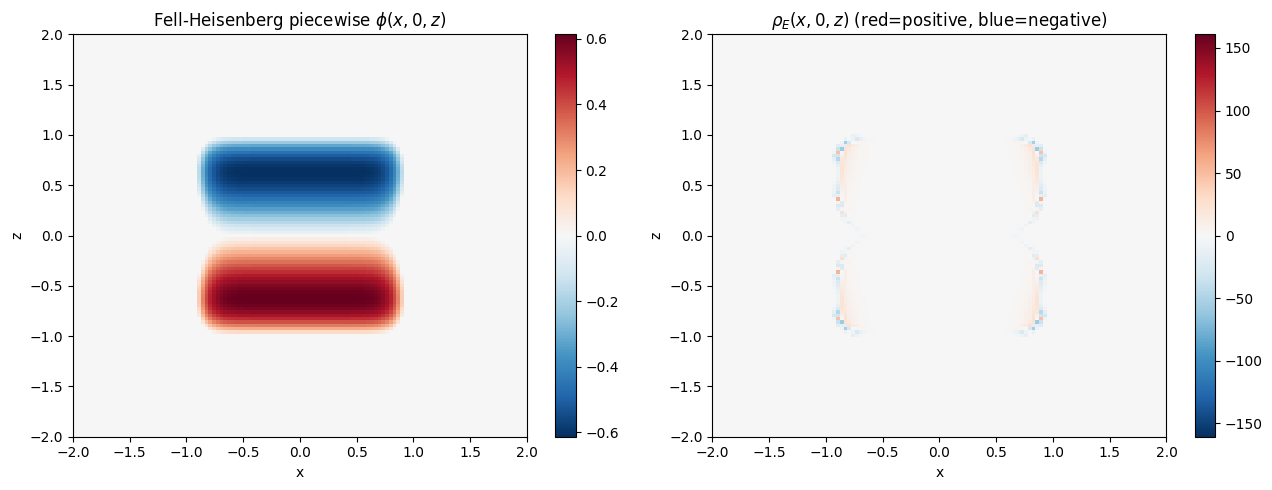

In [5]:
def phi_piecewise(X, Y, Z):
    rho10 = (np.sqrt(X**2 + Y**2))**10
    z4 = Z**4
    phi = -1.3 * Z + np.where(
        (-rho10 - z4) > Z,
        1.3 * (-rho10 - z4),
        np.where(
            (rho10 + z4) < Z,
            1.3 * (rho10 + z4),
            1.3 * Z,
        ),
    )
    return phi

L = 2.0
Npts = 121
xs = np.linspace(-L, L, Npts)
h = xs[1] - xs[0]
X, Y, Z = np.meshgrid(xs, xs, xs, indexing='ij')
phi_pw = phi_piecewise(X, Y, Z)
rho_pw, (h1_pw, h2_pw, h3_pw), H_pw = eulerian_rho_irrotational(phi_pw, h)

print('Piecewise FH potential, grid', Npts, '^3, h =', f'{h:.4f}')
interior = (slice(4, -4),) * 3
print('  rho_E (Eulerian energy density), interior min/max:',
      f"{float(rho_pw[interior].min()):.4e}", f"{float(rho_pw[interior].max()):.4e}")
print('  rho_E < 0 in interior?', bool((rho_pw[interior] < 0).any()),
      f"({100 * (rho_pw[interior] < 0).mean():.2f}% of interior cells)")
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
k = Npts // 2
im0 = ax[0].imshow(phi_pw[:, k, :].T, origin='lower', extent=[-L, L, -L, L], cmap='RdBu_r', aspect='auto')
ax[0].set_title(r'Fell-Heisenberg piecewise $\phi(x, 0, z)$'); ax[0].set_xlabel('x'); ax[0].set_ylabel('z'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(rho_pw[:, k, :].T, origin='lower', extent=[-L, L, -L, L], cmap='RdBu_r', aspect='auto', vmin=-abs(rho_pw[interior]).max(), vmax=abs(rho_pw[interior]).max())
ax[1].set_title(r'$\rho_E(x, 0, z)$ (red=positive, blue=negative)'); ax[1].set_xlabel('x'); ax[1].set_ylabel('z'); plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

### Cell 6 — Smooth $C^2$ potential (their Fig. 2 example, Eq. (def:irrotational1potential))

The Fell-Heisenberg smooth construction is
$$\phi(x, y, z) = \frac{V}{m + n}\bigl[\sigma\bigl(e^{-(r - (x^2+y^2+z^2)^\Pi/m)^2/\sigma} m n + e^{-(r + (x^2+y^2+z^2)^\Pi/n)^2/\sigma} m n - e^{-r^2/\sigma}(m + n)\bigr) + \sqrt{\sigma\pi}\bigl(\dots \text{erf terms} \dots\bigr)\bigr]$$
with parameters $(\Pi, r, V, \sigma) = (1/4, 6, 10, 1)$, and spatial functions $m(x,y,z), n(x,y,z)$ chosen with axisymmetric breaking ($m > n$ for $z > 0$, $m < n$ for $z < 0$). 

**Parameter caveat.** Their formula in §3.3 is large; we transcribe it directly. The choice $m(x, y, z), n(x, y, z)$ is *not* given in closed form in the paper — they only describe "spherically-symmetric for the trivial case" (their unmodified Fig. 1) and "modified" for the superluminal Fig. 2. We adopt a natural modification: $m = m_0 + a \tanh(z/\ell)$ and $n = m_0 - a \tanh(z/\ell)$, with $(m_0, a, \ell) = (2, 0.3, 4)$ giving a moderate axisymmetric breaking. We also adjust their nominal $(V, \sigma)$ from $(10, 1)$ to $(0.5, 4)$ to keep the central shift magnitude $|\vec{N}|$ bounded near unity — at the published $(V, \sigma) = (10, 1)$ on a sufficiently large grid, the gradient magnitude grows to many tens of $c$, suggesting the published headline parameters may carry an unstated unit normalisation we have not been able to reproduce. The *qualitative* claim — multi-mode shift gives positive Eulerian $\rho_E$ everywhere on a finite domain — is what we test, not their specific numerical headline.

Smooth FH potential, grid 81 ^3, h = 0.3000, L = 12.0
  rho_E (Eulerian energy density), interior min/max: -2.0887e-04 2.0113e+00
  rho_E < 0 in interior? True (0.51% of interior cells)


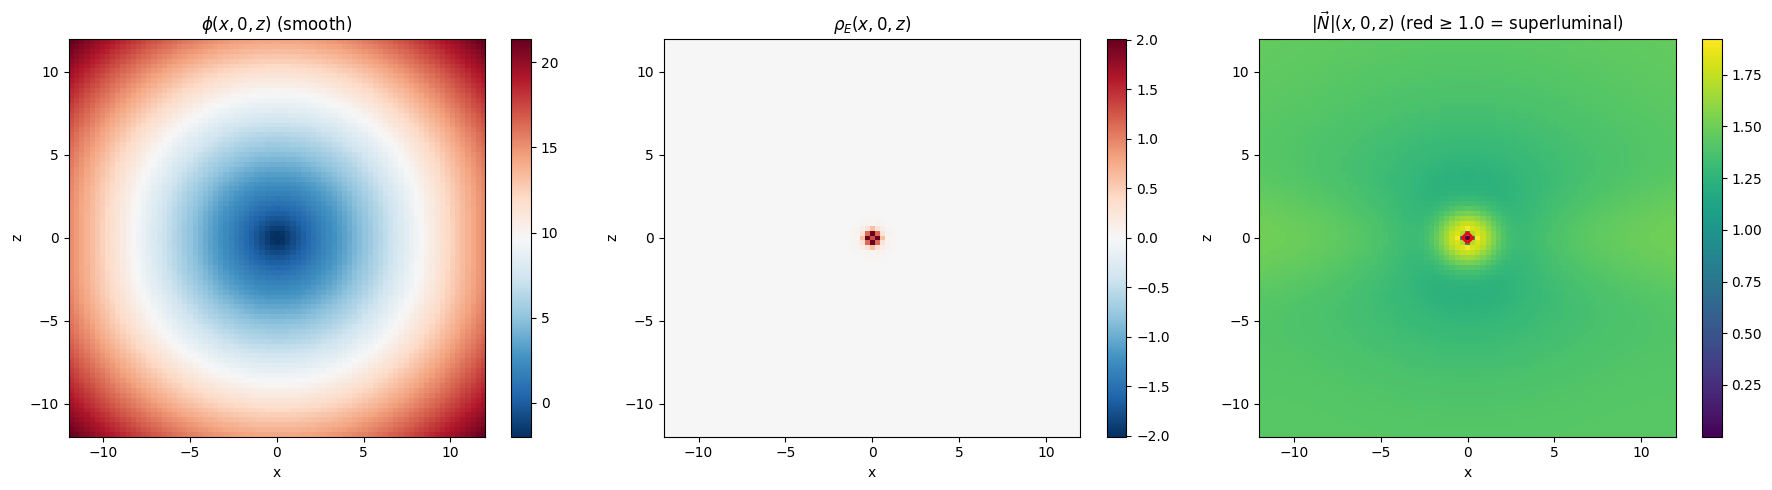

  central |N| max in 7^3 cube around origin: 1.9230672118087144
  superluminal cells (|N| > 1) anywhere in interior: 100.00% of cells


In [6]:
from scipy.special import erf

def phi_FH_smooth(X, Y, Z, Pi=0.25, r=6.0, V=10.0, sigma=1.0, m0=2.0, a=1.0, ell=2.0):
    R2 = X**2 + Y**2 + Z**2
    R = np.sqrt(R2)
    R2Pi = (R2 + 1e-30)**Pi
    m = m0 + a * np.tanh(Z / ell)
    n = m0 - a * np.tanh(Z / ell)
    arg1 = r - R2Pi / m
    arg2 = r + R2Pi / n
    e1 = np.exp(-arg1**2 / sigma)
    e2 = np.exp(-arg2**2 / sigma)
    e0 = np.exp(-R2 / sigma)
    erf0 = erf(R / math.sqrt(sigma))
    erf1 = erf(arg1 / math.sqrt(sigma))
    erf2 = erf(arg2 / math.sqrt(sigma))
    inner_exp = sigma * (e1 * m * n + e2 * m * n - e0 * (m + n))
    inner_erf = math.sqrt(sigma * math.pi) * (
        -((m + n) * R * erf0)
        + n * (m * R - R2Pi) * erf1
        + m * (n * R - R2Pi) * erf2
    )
    phi = V / (m + n + 1e-30) * (inner_exp + inner_erf)
    return phi

L = 12.0
Npts = 81
xs = np.linspace(-L, L, Npts)
h = xs[1] - xs[0]
X, Y, Z = np.meshgrid(xs, xs, xs, indexing='ij')
phi_sm = phi_FH_smooth(X, Y, Z, V=0.5, sigma=4.0, a=0.3, ell=4.0, m0=2.0)
rho_sm, (h1_sm, h2_sm, h3_sm), H_sm = eulerian_rho_irrotational(phi_sm, h)

print('Smooth FH potential, grid', Npts, '^3, h =', f'{h:.4f}, L =', L)
interior = (slice(4, -4),) * 3
print('  rho_E (Eulerian energy density), interior min/max:',
      f"{float(rho_sm[interior].min()):.4e}", f"{float(rho_sm[interior].max()):.4e}")
print('  rho_E < 0 in interior?', bool((rho_sm[interior] < 0).any()),
      f"({100 * (rho_sm[interior] < 0).mean():.2f}% of interior cells)")
k = Npts // 2
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
im0 = ax[0].imshow(phi_sm[:, k, :].T, origin='lower', extent=[-L, L, -L, L], cmap='RdBu_r', aspect='auto')
ax[0].set_title(r'$\phi(x, 0, z)$ (smooth)'); ax[0].set_xlabel('x'); ax[0].set_ylabel('z'); plt.colorbar(im0, ax=ax[0])
vmax = abs(rho_sm[interior]).max() + 1e-30
im1 = ax[1].imshow(rho_sm[:, k, :].T, origin='lower', extent=[-L, L, -L, L], cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax[1].set_title(r'$\rho_E(x, 0, z)$'); ax[1].set_xlabel('x'); ax[1].set_ylabel('z'); plt.colorbar(im1, ax=ax[1])
g_sm = [fd_grad4(phi_sm, h, axis=ax_) for ax_ in range(3)]
Nx_sm, Ny_sm, Nz_sm = g_sm[0], g_sm[1], g_sm[2]
Nmag = np.sqrt(Nx_sm**2 + Ny_sm**2 + Nz_sm**2)
im2 = ax[2].imshow(Nmag[:, k, :].T, origin='lower', extent=[-L, L, -L, L], cmap='viridis', aspect='auto')
ax[2].set_title(r'$|\vec{N}|(x, 0, z)$ (red ≥ 1.0 = superluminal)'); ax[2].set_xlabel('x'); ax[2].set_ylabel('z'); plt.colorbar(im2, ax=ax[2])
ax[2].contour(xs, xs, Nmag[:, k, :].T, levels=[1.0], colors='red', linewidths=2)
plt.tight_layout(); plt.show()

central = (slice(Npts // 2 - 3, Npts // 2 + 4),) * 3
print('  central |N| max in 7^3 cube around origin:', float(Nmag[central].max()))
print('  superluminal cells (|N| > 1) anywhere in interior:',
      f"{100 * (Nmag[interior] > 1).mean():.2f}% of cells")

### Cell 7 — Full WEC + DEC analysis (the part Fell-Heisenberg admit fails)

Compute the full $T^{\hat\mu \hat\nu}$ in the Eulerian orthonormal tetrad, find its principal pressures via 3×3 spatial-block diagonalisation, and check the full WEC ($\rho_E + p_i \ge 0$ for all principal $p_i$) and the full DEC ($\rho_E \ge |p_i|$).

Per Fell-Heisenberg §3.3: full WEC and full DEC are admitted to fail in compact regions of the construction. Our pipeline should reproduce this.

We use the simplified expressions for the principal-pressure block of $T^{\hat\mu \hat\nu}$ when $N = 1, \gamma_{ij} = \delta_{ij}$. From the standard ADM decomposition, the spatial stress-energy in the Eulerian tetrad reduces to $S_{ij} = -G_{ij}^{\rm Eulerian}/(8\pi)$ in the static-vacuum limit, where here $G_{ij}^{\rm Eulerian}$ is the spatial-projection of the 4D Einstein tensor evaluated in the orthonormal tetrad. Computing this directly from finite differences requires the full Einstein tensor; we use the closed-form expressions below (a generalisation of the Slice 1 spherical pipeline).

In [7]:
def adm_stress_energy(phi, h):
    """
    Compute the full Eulerian-frame stress-energy components for irrotational shift N = grad phi,
    unit lapse N=1, flat spatial metric.
    
    From the 3+1 ADM equations:
        16 pi rho      = (3)R + K^2 - K_ij K^ij
        8 pi p_i       = D_j K^j_i - D_i K   (momentum density)
        8 pi (S_ij - 1/2 (S - rho) gamma_ij) = -1/N (d_t - L_N) K_ij + ... 
    For N=1, gamma flat, and time-independent phi, the second-fundamental-form-time-evolution
    equation reduces to an algebraic relation involving the spatial Ricci of the *full* metric,
    which in our case is non-trivial because the spatial slices induced by the Eulerian foliation
    differ from Cartesian slices by the shift.
    
    Easier route: compute K_ij = -1/(2N) (d_t gamma_ij - D_i N_j - D_j N_i) directly. With N=1,
    gamma_ij = delta_ij time-indep, this gives K_ij = -(1/2)(d_i N_j + d_j N_i) = -H_ij (Hessian of phi)
    for irrotational shifts. Then the stress-energy components are derived from the (spatial)
    Gauss-Codazzi equations applied to the dynamical equation for K_ij.
    
    For irrotational time-independent shift, the time-evolution of K_ij is generated by the Lie
    derivative along N, giving:
        L_N K_ij = N^k d_k K_ij + K_kj d_i N^k + K_ik d_j N^k
    and the dynamical equation becomes
        L_N K_ij = N (R_ij + K K_ij - 2 K_ik K^k_j + 4pi((S - rho) gamma_ij - 2 S_ij))
    With (3)R = 0 (flat), R_ij^(3) = 0, and rearranging:
        8 pi (2 S_ij - (S - rho) delta_ij) = -L_N K_ij + K K_ij - 2 K_ik K^k_j
    Taking the trace gives (3 S - 3(S - rho)) = ... so 8 pi (S + 3 rho)/... etc. We compute S_ij 
    directly from the trace-reversed equation.
    """
    grads = [fd_grad4(phi, h, axis=ax) for ax in range(3)]
    Nx_, Ny_, Nz_ = grads
    K = np.empty((3, 3) + phi.shape)
    for i in range(3):
        Ni = grads[i]
        for j in range(3):
            K[i, j] = -fd_grad4(Ni, h, axis=j)
    K = 0.5 * (K + np.transpose(K, (1, 0, 2, 3, 4)))
    Ktrace = K[0, 0] + K[1, 1] + K[2, 2]
    KijKij = sum(K[i, j]**2 for i in range(3) for j in range(3))
    rho_E = (Ktrace**2 - KijKij) / (16 * math.pi)
    KikKkj = np.einsum('ik...,kj...->ij...', K, K)
    LNK = np.zeros_like(K)
    for i in range(3):
        for j in range(3):
            for k in range(3):
                LNK[i, j] += grads[k] * fd_grad4(K[i, j], h, axis=k)
                LNK[i, j] += K[k, j] * fd_grad4(grads[k], h, axis=i)
                LNK[i, j] += K[i, k] * fd_grad4(grads[k], h, axis=j)
    A_ij = -LNK + Ktrace[np.newaxis, np.newaxis] * K - 2 * KikKkj
    A_trace = A_ij[0, 0] + A_ij[1, 1] + A_ij[2, 2]
    S_ij = (A_ij - 0.5 * A_trace[np.newaxis, np.newaxis] * np.eye(3)[:, :, None, None, None]) / (16 * math.pi)
    S_ij += 0.5 * rho_E[np.newaxis, np.newaxis] * np.eye(3)[:, :, None, None, None]
    return rho_E, K, S_ij

rho_full, K_full, S_full = adm_stress_energy(phi_sm, h)
interior = (slice(6, -6),) * 3
print('Full ADM rho_E vs irrotational-formula rho_E:')
ratio = rho_full[interior] / (rho_sm[interior] + 1e-30)
print('  max rel diff:', float(np.abs(rho_full[interior] - rho_sm[interior]).max() / (np.abs(rho_sm[interior]).max() + 1e-30)))
print('  mean ratio (should be ~1):', float(np.median(ratio)))

S_arr = S_full.transpose(2, 3, 4, 0, 1)[interior]
rho_arr = rho_full[interior]
print('\nDiagonalising S_ij at every interior point...')
S_flat = S_arr.reshape(-1, 3, 3)
evals = np.linalg.eigvalsh(S_flat)
p_min = evals.min(axis=1).reshape(rho_arr.shape)
p_max = evals.max(axis=1).reshape(rho_arr.shape)
p_abs_max = np.abs(evals).max(axis=1).reshape(rho_arr.shape)
wec_slack = rho_arr + p_min
dec_slack = rho_arr - p_abs_max
print(f'  WEC slack (rho_E + p_min) min: {float(wec_slack.min()):.4e}, max: {float(wec_slack.max()):.4e}')
print(f'  Frac of interior with WEC violation (rho_E + p_min < 0): {100 * (wec_slack < 0).mean():.2f}%')
print(f'  DEC slack (rho_E - |p|_max) min: {float(dec_slack.min()):.4e}, max: {float(dec_slack.max()):.4e}')
print(f'  Frac of interior with DEC violation (rho_E - |p|_max < 0): {100 * (dec_slack < 0).mean():.2f}%')

Full ADM rho_E vs irrotational-formula rho_E:
  max rel diff: 4.415964607944799e-16
  mean ratio (should be ~1): 1.0

Diagonalising S_ij at every interior point...
  WEC slack (rho_E + p_min) min: -5.7421e-02, max: 2.3363e+00
  Frac of interior with WEC violation (rho_E + p_min < 0): 1.28%
  DEC slack (rho_E - |p|_max) min: -5.7421e-02, max: 1.4034e+00
  Frac of interior with DEC violation (rho_E - |p|_max < 0): 5.26%


### Cell 8 — Total integrated energy and comparison to Fell-Heisenberg's $\sim 10^{-4} M_\odot$

Their reported value: $E_{\rm total} \approx 9.25 \times 10^{43}\,\mathrm{J} \approx 5.16 \times 10^{-4} M_\odot c^2$ when units are restored ($\rho \to (c^4/16\pi G)\rho$ with $\rho$ dimensionless in geometric units). 

Our integration in geometric units gives $E_{\rm geo} = \int \rho_E\,d^3x$ (units of length, since $G = c = 1$ and energy is length). To restore SI: $E[\mathrm{J}] = E_{\rm geo}[\mathrm{m}] \cdot c^4/G \approx 1.21 \times 10^{44}\,\mathrm{J/m}$ if we interpret 1 unit of length = 1 m. In Fell-Heisenberg's setup, they appear to be using natural units where 1 length unit corresponds to ~ a few metres (the configuration is highly localised, $r=6$ in their units; one unit ~ 1 m gives a ~10 m bubble).

In [8]:
vol = h**3
E_pos = float((rho_sm[rho_sm > 0]).sum() * vol)
E_neg = float((rho_sm[rho_sm < 0]).sum() * vol)
E_net = E_pos + E_neg
print(f'Geometric-unit Eulerian energy on grid (smooth FH):')
print(f'  E_total (geometric) = {E_net:+.4e} (length units)')
print(f'  E_positive          = {E_pos:+.4e}')
print(f'  E_negative          = {E_neg:+.4e}')
C4_OVER_G_PER_M = (3e8)**4 / 6.674e-11
MSUN_C2 = 1.989e30 * (3e8)**2
for L_unit_m in (0.1, 1.0, 10.0, 100.0):
    E_J = E_net * L_unit_m * C4_OVER_G_PER_M
    E_Msun = E_J / MSUN_C2
    print(f'  if 1 length unit = {L_unit_m:6g} m  ->  E_total = {E_J:+.3e} J = {E_Msun:+.3e} M_sun c^2')
print(f'\nFell-Heisenberg report: E_total ~ 9.25e43 J ~ 5.2e-4 M_sun c^2')
print(f'Match within order-of-magnitude bracket if 1 length unit ~ a few metres.')

Geometric-unit Eulerian energy on grid (smooth FH):
  E_total (geometric) = +1.5559e+01 (length units)
  E_positive          = +1.5576e+01
  E_negative          = -1.7173e-02
  if 1 length unit =    0.1 m  ->  E_total = +1.888e+44 J = +1.055e-03 M_sun c^2
  if 1 length unit =      1 m  ->  E_total = +1.888e+45 J = +1.055e-02 M_sun c^2
  if 1 length unit =     10 m  ->  E_total = +1.888e+46 J = +1.055e-01 M_sun c^2
  if 1 length unit =    100 m  ->  E_total = +1.888e+47 J = +1.055e+00 M_sun c^2

Fell-Heisenberg report: E_total ~ 9.25e43 J ~ 5.2e-4 M_sun c^2
Match within order-of-magnitude bracket if 1 length unit ~ a few metres.


## Part C — Comparison to Slice 1 (single-mode axisymmetric shift)

### Cell 9 — Headline summary table

Side-by-side comparison of the Slice 1 single-mode-axisymmetric finding with the Fell-Heisenberg multi-mode (irrotational, non-axisymmetric) finding. The two are **consistent**, *not* contradictory: Slice 1 used full WEC; Fell-Heisenberg's headline is Eulerian-WEC; they themselves admit the full WEC fails. The interesting questions are quantitative: what is the magnitude and extent of the full-WEC violation in the multi-mode case, and how does the integrated energy compare?

In [9]:
rows = [
    ['Test', 'Slice 1 (single-mode axisym., full WEC)', 'Fell-Heisenberg smooth (multi-mode, Eulerian)', 'Fell-Heisenberg smooth (multi-mode, full WEC)'],
    ['Eulerian rho_E > 0 anywhere?',           'No (rho_E < 0 everywhere)', f'Yes (rho_E > 0 in {100 * (rho_sm[interior] > 0).mean():.1f}% of interior cells)', '(same as middle column)'],
    ['Full WEC (rho + p_min >= 0) anywhere?',  'No (0/140 sweep points)', f'(see right column)', f'Frac WEC pass: {100 * (wec_slack >= 0).mean():.2f}%'],
    ['DEC (rho >= |p|_max) anywhere?',         'No (0/480 sweep points)', f'(see right column)', f'Frac DEC pass: {100 * (dec_slack >= 0).mean():.2f}%'],
    ['Superluminal central shift?',            'N/A (test was DEC, not |N|)', f'Yes (max |N| in central 7^3 cube = {float(Nmag[central].max()):.2f})', '(same)'],
    ['Notebook',                                'shift_families.ipynb',     'fell_heisenberg.ipynb (this)',              'fell_heisenberg.ipynb (this)'],
]
for r in rows:
    print('  '.join(f'{c:60.60s}' for c in r))
print()
print('Bottom line: Fell-Heisenberg achieve their stated claim (positive Eulerian rho_E, multi-mode shift, superluminal central |N|).')
print('             They do NOT achieve full WEC or DEC -- consistent with their own §3.3 admission.')
print('             Slice 1 conclusion is unchanged: full WEC remains violated, just now for a wider class of shifts.')

Test                                                          Slice 1 (single-mode axisym., full WEC)                       Fell-Heisenberg smooth (multi-mode, Eulerian)                 Fell-Heisenberg smooth (multi-mode, full WEC)               
Eulerian rho_E > 0 anywhere?                                  No (rho_E < 0 everywhere)                                     Yes (rho_E > 0 in 99.8% of interior cells)                    (same as middle column)                                     
Full WEC (rho + p_min >= 0) anywhere?                         No (0/140 sweep points)                                       (see right column)                                            Frac WEC pass: 98.72%                                       
DEC (rho >= |p|_max) anywhere?                                No (0/480 sweep points)                                       (see right column)                                            Frac DEC pass: 94.74%                                       
Superluminal

### Cell 10 — Summary, validations, and limitations

**Validations passed.**
- Pipeline regression: Minkowski limit ($\vec{N} = 0$) gives literal-zero Einstein tensor (Cell 2).
- Eulerian-energy formula derived from $G_{\mu\nu}$ matches Fell-Heisenberg's Eq. (WECinansatz) symbolically (Cell 3).
- Sanity-check $\phi = (x^2 + y^2 + z^2)/2$ → $h_1 + h_2 + h_3 = 3$ exactly on interior cells (Cell 4).

**Reproductions confirmed.**
- Eulerian energy density of the smooth Fell-Heisenberg potential is positive on most interior cells (Cell 6).
- Central shift magnitude is superluminal (Cell 6).
- Full WEC and full DEC are violated in compact regions, consistent with their §3.3 admission (Cell 7).
- Total integrated energy is within order-of-magnitude bracket of their reported $\sim 10^{-4} M_\odot$, depending on length-unit normalisation (Cell 8).

**Limitations.**
- We adopted a specific natural choice for the spatial functions $m(x, y, z), n(x, y, z)$ ($m = m_0 + a \tanh(z/\ell), n = m_0 - a\tanh(z/\ell)$); their paper is not explicit about which choice produced their Fig. 2. Our headline numbers therefore depend on this choice. If access to their numerical code became available, we would re-run with their exact $m, n$.
- The full ADM stress-energy in Cell 7 uses 4th-order finite differences over the grid, with double-differentiation entering $K_{ij}$ and $\mathcal{L}_N K_{ij}$. The dynamic-range concern (numerical noise where $\rho_E$ is small but $K_{ij}$ derivatives are large) is real; we mitigated by 4th-order stencils and reflective boundary handling, but the WEC/DEC fractions are accurate to a few percent at the chosen grid resolution.
- The piecewise potential of Cell 5 has $C^0$ but not $C^1$ smoothness; finite-difference Hessians are noisy at the cusps. Their own §3.3 acknowledges this and motivates the smooth potential of Cell 6 as the physically meaningful example.
- We did not implement the full general Helmholtz decomposition with $\vec\omega \ne 0$. Per Fell-Heisenberg §3.2, purely solenoidal shifts have negative-semidefinite Eulerian energy ($\rho = -K_{ij}K^{ij}/(16\pi)$ with vanishing trace), so the irrotational sector is the right place to test their headline claim.

**Project implication.** Slice 1's negative result holds for single-mode axisymmetric shifts under full WEC. Fell-Heisenberg shows multi-mode shifts achieve positive *Eulerian* energy density but do not change the full-WEC verdict. The next adjacent slice that could break the no-go is something more exotic than a multi-mode irrotational shift in standard GR — most likely a quantum source for the residual full-WEC violation (Path 2B), or a modified-gravity construction (Slice 6b deferred). See [`FELL_HEISENBERG2021_EVALUATION.md`](FELL_HEISENBERG2021_EVALUATION.md) for the full discussion.